# 제주 농산물 가격 예측 프로젝트 - 최종 통합 및 예측 시각화 (CLI17)

## 1. 환경 설정 및 데이터 로드

In [1]:
import os
import pandas as pd
import numpy as np
import datetime
import holidays
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# 폰트 설정
try:
    from korean_font import set_korean_font
    set_korean_font()
    print("korean_font.py 설정 완료")
except:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False
    print("시스템 폰트(Malgun Gothic) 설정 완료")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import VotingRegressor

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

DATA_PATH = './data/'
train = pd.read_csv(os.path.join(DATA_PATH, 'train.csv'))
test = pd.read_csv(os.path.join(DATA_PATH, 'test.csv'))
train['timestamp'] = pd.to_datetime(train['timestamp'])
test['timestamp'] = pd.to_datetime(test['timestamp'])

print(f"데이터 로드 완료. Train: {train.shape}")

한글 폰트 설정: NanumGothic (/usr/share/fonts/truetype/nanum/NanumGothic.ttf)
korean_font.py 설정 완료


2026-03-17 14:52:41.658910: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


데이터 로드 완료. Train: (59397, 7)


## 2. 통합 데이터 분석 (EDA)

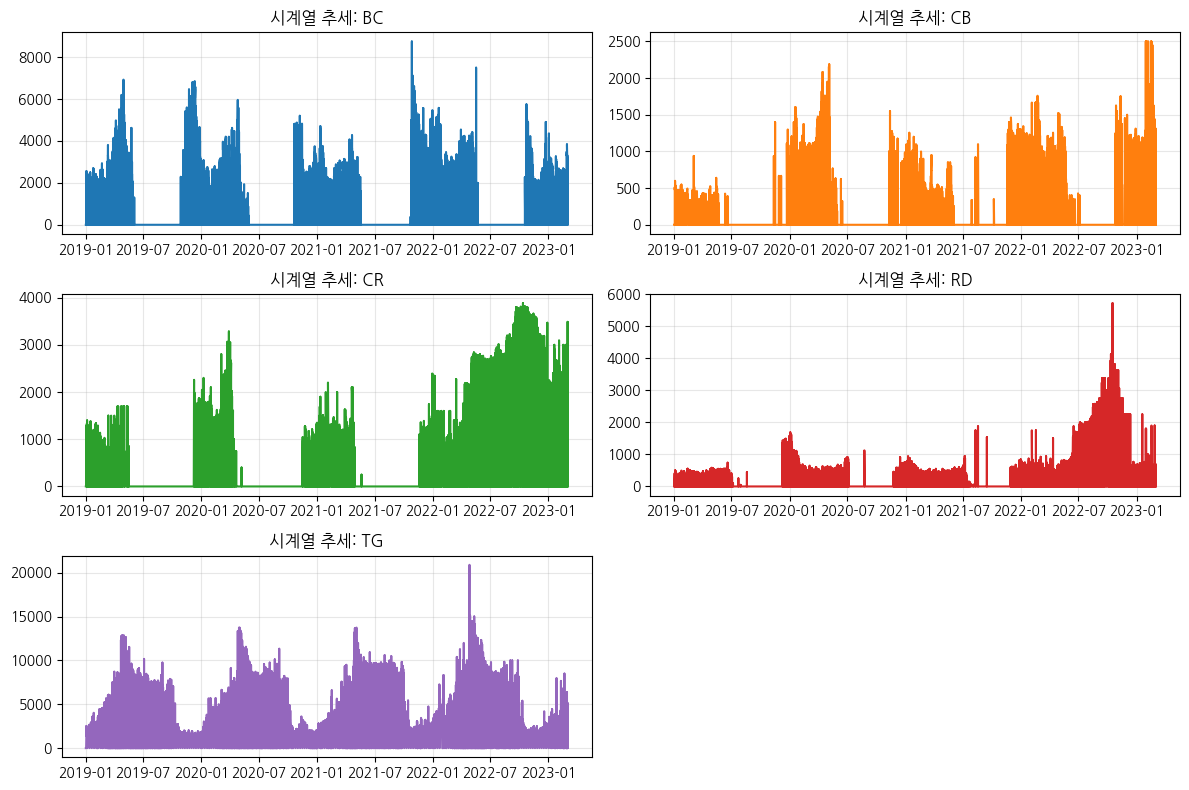

In [2]:
items = sorted(train['item'].unique())
plt.figure(figsize=(12,8))
for i, item in enumerate(items):
    plt.subplot(3, 2, i+1)
    item_data = train[train['item'] == item].sort_values('timestamp')
    plt.plot(item_data['timestamp'], item_data['price(원/kg)'], label=item, color=f'C{i}')
    plt.title(f'시계열 추세: {item}')
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

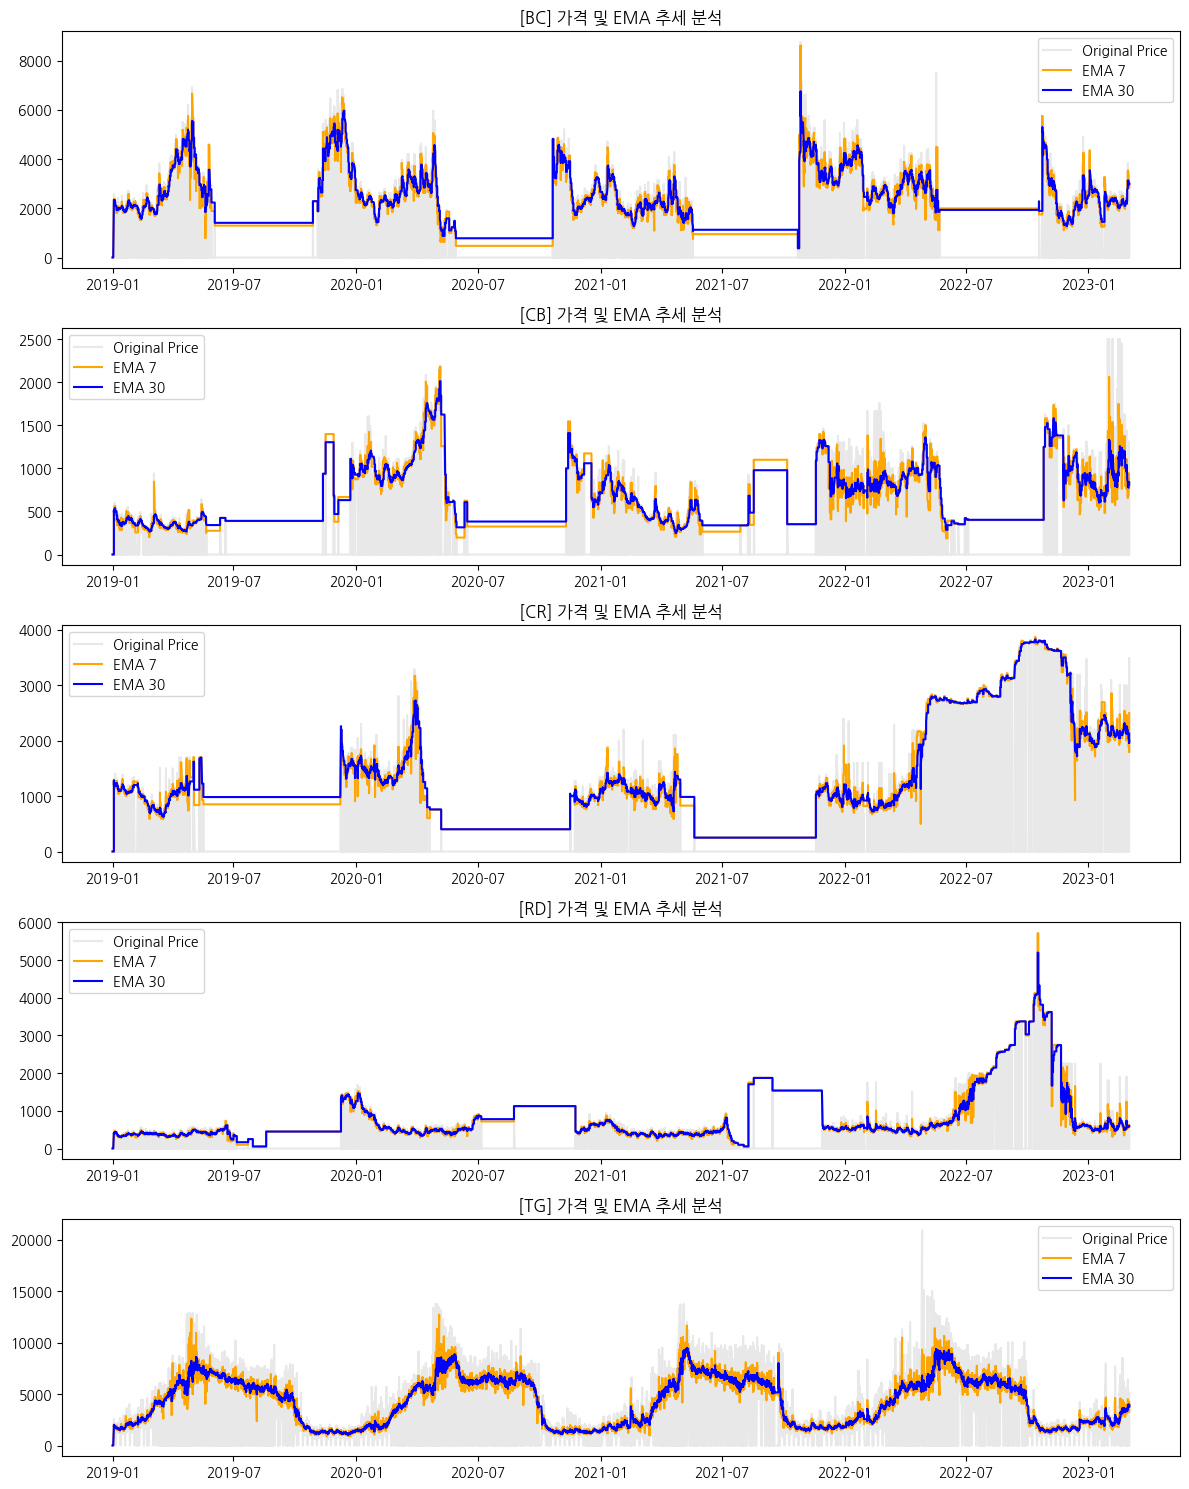

In [3]:
def calculate_ema_viz(series, window):
    s = series.replace(0, np.nan)
    ema = s.ewm(span=window, min_periods=1).mean()
    return ema.ffill().fillna(0)

plt.figure(figsize=(12, 15))
for i, item in enumerate(items):
    plt.subplot(5, 1, i+1)
    df_item = train[train['item'] == item].sort_values('timestamp').copy()
    df_item['ema_7'] = calculate_ema_viz(df_item['price(원/kg)'], 7)
    df_item['ema_30'] = calculate_ema_viz(df_item['price(원/kg)'], 30)
    plt.plot(df_item['timestamp'], df_item['price(원/kg)'], label='Original Price', color='lightgray', alpha=0.5)
    plt.plot(df_item['timestamp'], df_item['ema_7'], label='EMA 7', color='orange')
    plt.plot(df_item['timestamp'], df_item['ema_30'], label='EMA 30', color='blue')
    plt.title(f'[{item}] 가격 및 EMA 추세 분석')
    plt.legend()
plt.tight_layout()
plt.show()

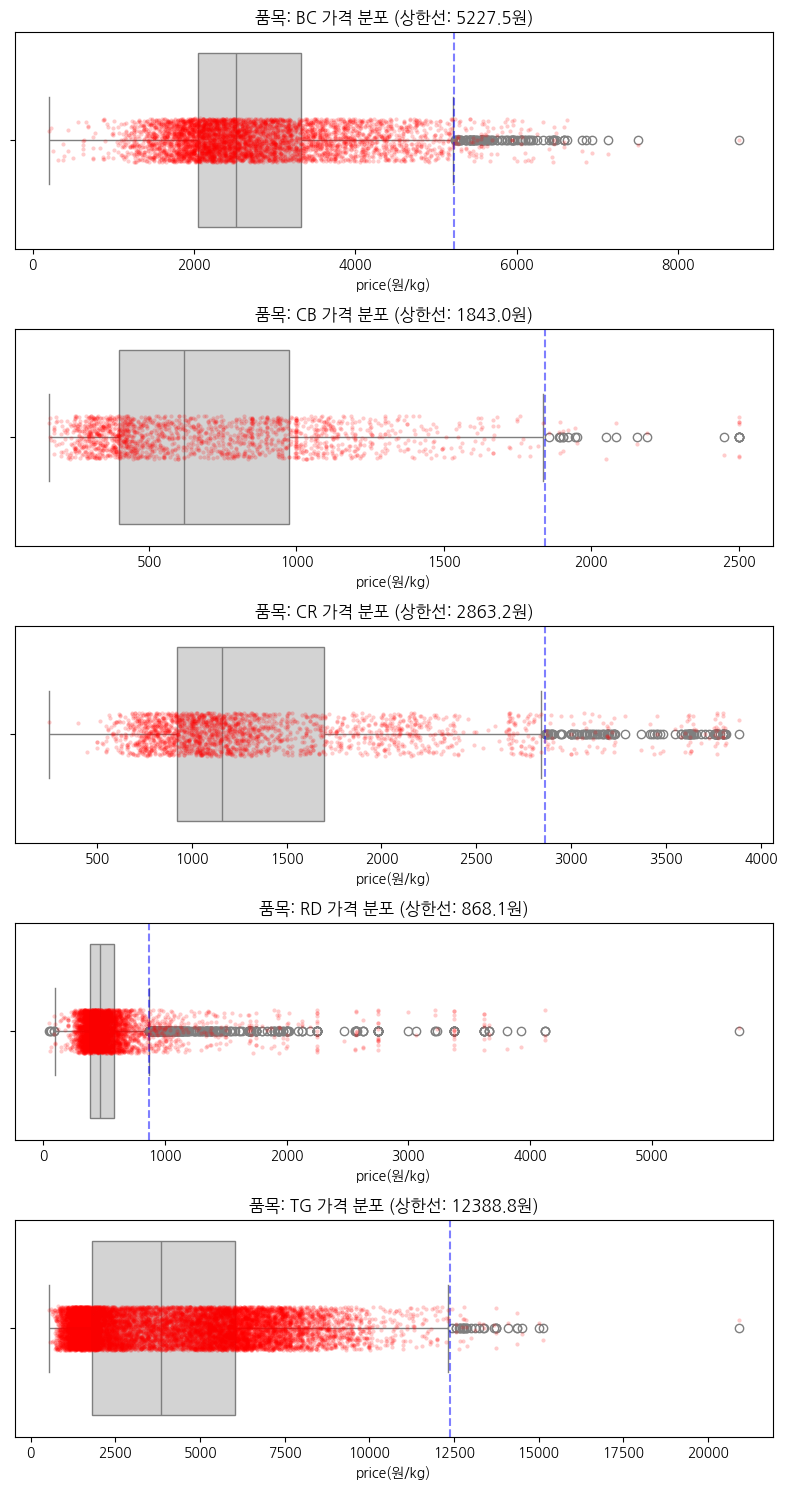

In [4]:
fig, axes = plt.subplots(5, 1, figsize=(8, 15))
for i, item_name in enumerate(items):
    target_df = train[(train['item'] == item_name) & (train['price(원/kg)'] > 0)]
    Q1 = target_df['price(원/kg)'].quantile(0.25)
    Q3 = target_df['price(원/kg)'].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    sns.boxplot(data=target_df, x='price(원/kg)', ax=axes[i], color='lightgray')
    sns.stripplot(data=target_df, x='price(원/kg)', ax=axes[i], color='red', alpha=0.2, size=3)
    axes[i].axvline(upper_bound, color='blue', linestyle='--', alpha=0.5)
    axes[i].set_title(f"품목: {item_name} 가격 분포 (상한선: {upper_bound:.1f}원)")
plt.tight_layout()
plt.show()

## 3. 특성 공학 (Feature Engineering)

In [5]:
outlier_thresholds = {'TG': 20000, 'RD': 5000, 'BC': 8000, 'CB': 2300}
for item, thr in outlier_thresholds.items():
    mask = (train['item'] == item) & (train['price(원/kg)'] > thr)
    if mask.any():
        mean_val = train[(train['item'] == item) & (train['price(원/kg)'] > 0)]['price(원/kg)'].mean()
        train.loc[mask, 'price(원/kg)'] = mean_val

SEOLLAL = [pd.Timestamp(d) for d in ['2019-02-05', '2020-01-25', '2021-02-12', '2022-02-01', '2023-01-22']]
CHUSEOK = [pd.Timestamp(d) for d in ['2019-09-13', '2020-10-01', '2021-09-21', '2022-09-10', '2023-09-29']]

def final_preprocess(df):
    df['year'] = df['timestamp'].dt.year
    df['month'] = df['timestamp'].dt.month
    df['day'] = df['timestamp'].dt.day
    df['dow'] = df['timestamp'].dt.dayofweek
    df['week_num'] = (df['timestamp'] - pd.to_datetime('2019-01-01')).dt.days // 7
    df['dist_seollal'] = df['timestamp'].map(lambda d: min(min(abs((d - h).days) for h in SEOLLAL), 30))
    df['dist_chuseok'] = df['timestamp'].map(lambda d: min(min(abs((d - h).days) for h in CHUSEOK), 30))
    kr_h = holidays.KR()
    df['holiday'] = df['timestamp'].apply(lambda x: 1 if x in kr_h else 0)
    return df

train_processed = final_preprocess(train.copy())
test_processed = final_preprocess(test.copy())

def calc_ema(series, window):
    s = series.replace(0, np.nan)
    ema = s.shift(1).ewm(span=window, min_periods=1).mean()
    return ema.ffill().fillna(0)

for w in [7, 30]:
    train_processed[f'ema_{w}'] = train_processed.groupby(['item', 'corporation', 'location'])['price(원/kg)'].transform(lambda x: calc_ema(x, w))

last_ema = train_processed.groupby(['item', 'corporation', 'location'])[[f'ema_{7}', f'ema_{30}']].last().reset_index()
test_processed = pd.merge(test_processed, last_ema, on=['item', 'corporation', 'location'], how='left').fillna(0)
print("전처리 완료")

전처리 완료


## 4. 앙상블 모델링 with Hold-out Validation

In [6]:
le_cols = ['item', 'corporation', 'location']
le_dict = {col: LabelEncoder().fit(train_processed[col]) for col in le_cols}
for col in le_cols:
    train_processed[col] = le_dict[col].transform(train_processed[col])
    test_processed[col] = le_dict[col].transform(test_processed[col])

item_codes = {name: le_dict['item'].transform([name])[0] for name in le_dict['item'].classes_}
train_processed['target'] = np.where(train_processed['item'] == item_codes['TG'], np.sqrt(train_processed['price(원/kg)']), np.log1p(train_processed['price(원/kg)']))

feats = ['item', 'corporation', 'location', 'year', 'month', 'day', 'dow', 'week_num', 'holiday', 'dist_seollal', 'dist_chuseok', 'ema_7', 'ema_30']

def build_dnn(input_shape):
    model = keras.Sequential([
        layers.Dense(512, activation='relu', input_shape=(input_shape,)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mae')
    return model

def train_ensemble_holdout(train_df, test_df, feats, name=""):
    split_date = pd.Timestamp('2023-01-01')
    tr_data = train_df[train_df['timestamp'] < split_date]
    va_data = train_df[train_df['timestamp'] >= split_date]
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(tr_data[feats])
    X_va = scaler.transform(va_data[feats])
    X_te = scaler.transform(test_df[feats])
    y_tr = tr_data['target']
    y_va = va_data['target']
    tree_model = VotingRegressor([
        ('lgbm', LGBMRegressor(n_estimators=1000, learning_rate=0.01, random_state=SEED, verbose=-1)),
        ('xgb', XGBRegressor(n_estimators=1000, learning_rate=0.01, random_state=SEED)),
        ('cat', CatBoostRegressor(iterations=1000, learning_rate=0.01, random_state=SEED, verbose=0))
    ])
    tree_model.fit(X_tr, y_tr)
    tree_test_pred = tree_model.predict(X_te)
    dnn_model = build_dnn(len(feats))
    es = callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    dnn_model.fit(X_tr, y_tr, validation_data=(X_va, y_va), epochs=300, batch_size=64, callbacks=[es], verbose=0)
    dnn_test_pred = dnn_model.predict(X_te).flatten()
    final_test_pred = (tree_test_pred * 0.6) + (dnn_test_pred * 0.4)
    val_pred = (tree_model.predict(X_va) * 0.6) + (dnn_model.predict(X_va).flatten() * 0.4)
    mae = mean_absolute_error(y_va, val_pred)
    print(f"{name} Ensemble Hold-out MAE: {mae:.4f}")
    return final_test_pred

m1 = train_processed['item'] == item_codes['TG']
m2 = train_processed['item'].isin([item_codes['RD'], item_codes['CR']])
m3 = train_processed['item'].isin([item_codes['BC'], item_codes['CB']])

print("Group 1 학습 (TG)...")
p1 = train_ensemble_holdout(train_processed[m1], test_processed[test_processed['item']==item_codes['TG']], feats, "TG")
print("Group 2 학습 (RD, CR)...")
p2 = train_ensemble_holdout(train_processed[m2], test_processed[test_processed['item'].isin([item_codes['RD'], item_codes['CR']])], feats, "RD_CR")
print("Group 3 학습 (BC, CB)...")
p3 = train_ensemble_holdout(train_processed[m3], test_processed[test_processed['item'].isin([item_codes['BC'], item_codes['CB']])], feats, "BC_CB")

Group 1 학습 (TG)...


I0000 00:00:1773726805.224189   49654 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5562 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:01:00.0, compute capability: 8.6
2026-03-17 14:53:28.960779: I external/local_xla/xla/service/service.cc:163] XLA service 0x733bc8014530 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-17 14:53:28.960821: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3070, Compute Capability 8.6
2026-03-17 14:53:29.028935: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-17 14:53:29.466267: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-03-17 14:53:29.729834: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs wer

1/9 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step

2026-03-17 14:54:52.015361: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 14:54:52.015433: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 14:54:53.563660: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_79', 20 bytes spill stores, 20 bytes spill loads

2026-03-17 14:54:53.956695: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : R

9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 406ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step
TG Ensemble Hold-out MAE: 7.0384
Group 2 학습 (RD, CR)...


2026-03-17 14:55:45.576484: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 14:55:45.576726: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 14:55:45.576771: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 14:55:47.644175: I external/l

14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step
RD_CR Ensemble Hold-out MAE: 1.3649
Group 3 학습 (BC, CB)...


2026-03-17 14:58:11.830699: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 14:58:11.830765: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 14:58:11.830782: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-17 14:58:11.830799: I external/l

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 121ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
BC_CB Ensemble Hold-out MAE: 1.2484


## 5. 결과 통합 및 후처리

In [7]:
test_tg = test_processed[test_processed['item'] == item_codes['TG']].copy()
test_rd_cr = test_processed[test_processed['item'].isin([item_codes['RD'], item_codes['CR']])].copy()
test_bc_cb = test_processed[test_processed['item'].isin([item_codes['BC'], item_codes['CB']])].copy()
test_tg['answer'] = np.power(np.maximum(0, p1), 2)
test_rd_cr['answer'] = np.expm1(p2)
test_bc_cb['answer'] = np.expm1(p3)

final_df = pd.concat([test_tg, test_rd_cr, test_bc_cb])
inv_map = {v: k for k, v in item_codes.items()}
final_df['item_name'] = final_df['item'].map(inv_map)
th = {'TG': 400, 'CB': 50, 'RD': 10, 'CR': 150, 'BC': 100}
for it, val in th.items():
    final_df.loc[(final_df['item_name'] == it) & (final_df['answer'] < val), 'answer'] = 0
final_df.loc[final_df['dow'] == 6, 'answer'] = 0

sub = pd.read_csv('./data/sample_submission.csv')
sub = pd.merge(sub[['ID']], final_df[['ID', 'answer']], on='ID', how='left')
sub.to_csv('submission43.csv', index=False)
print("최종 결과 저장 완료 (submission43.csv)")

최종 결과 저장 완료 (submission43.csv)


## 6. 예측 결과 시각화 (Actual vs Prediction)
- 2023년 1월부터의 실제 데이터와 3월 예측 데이터를 연결하여 시각화

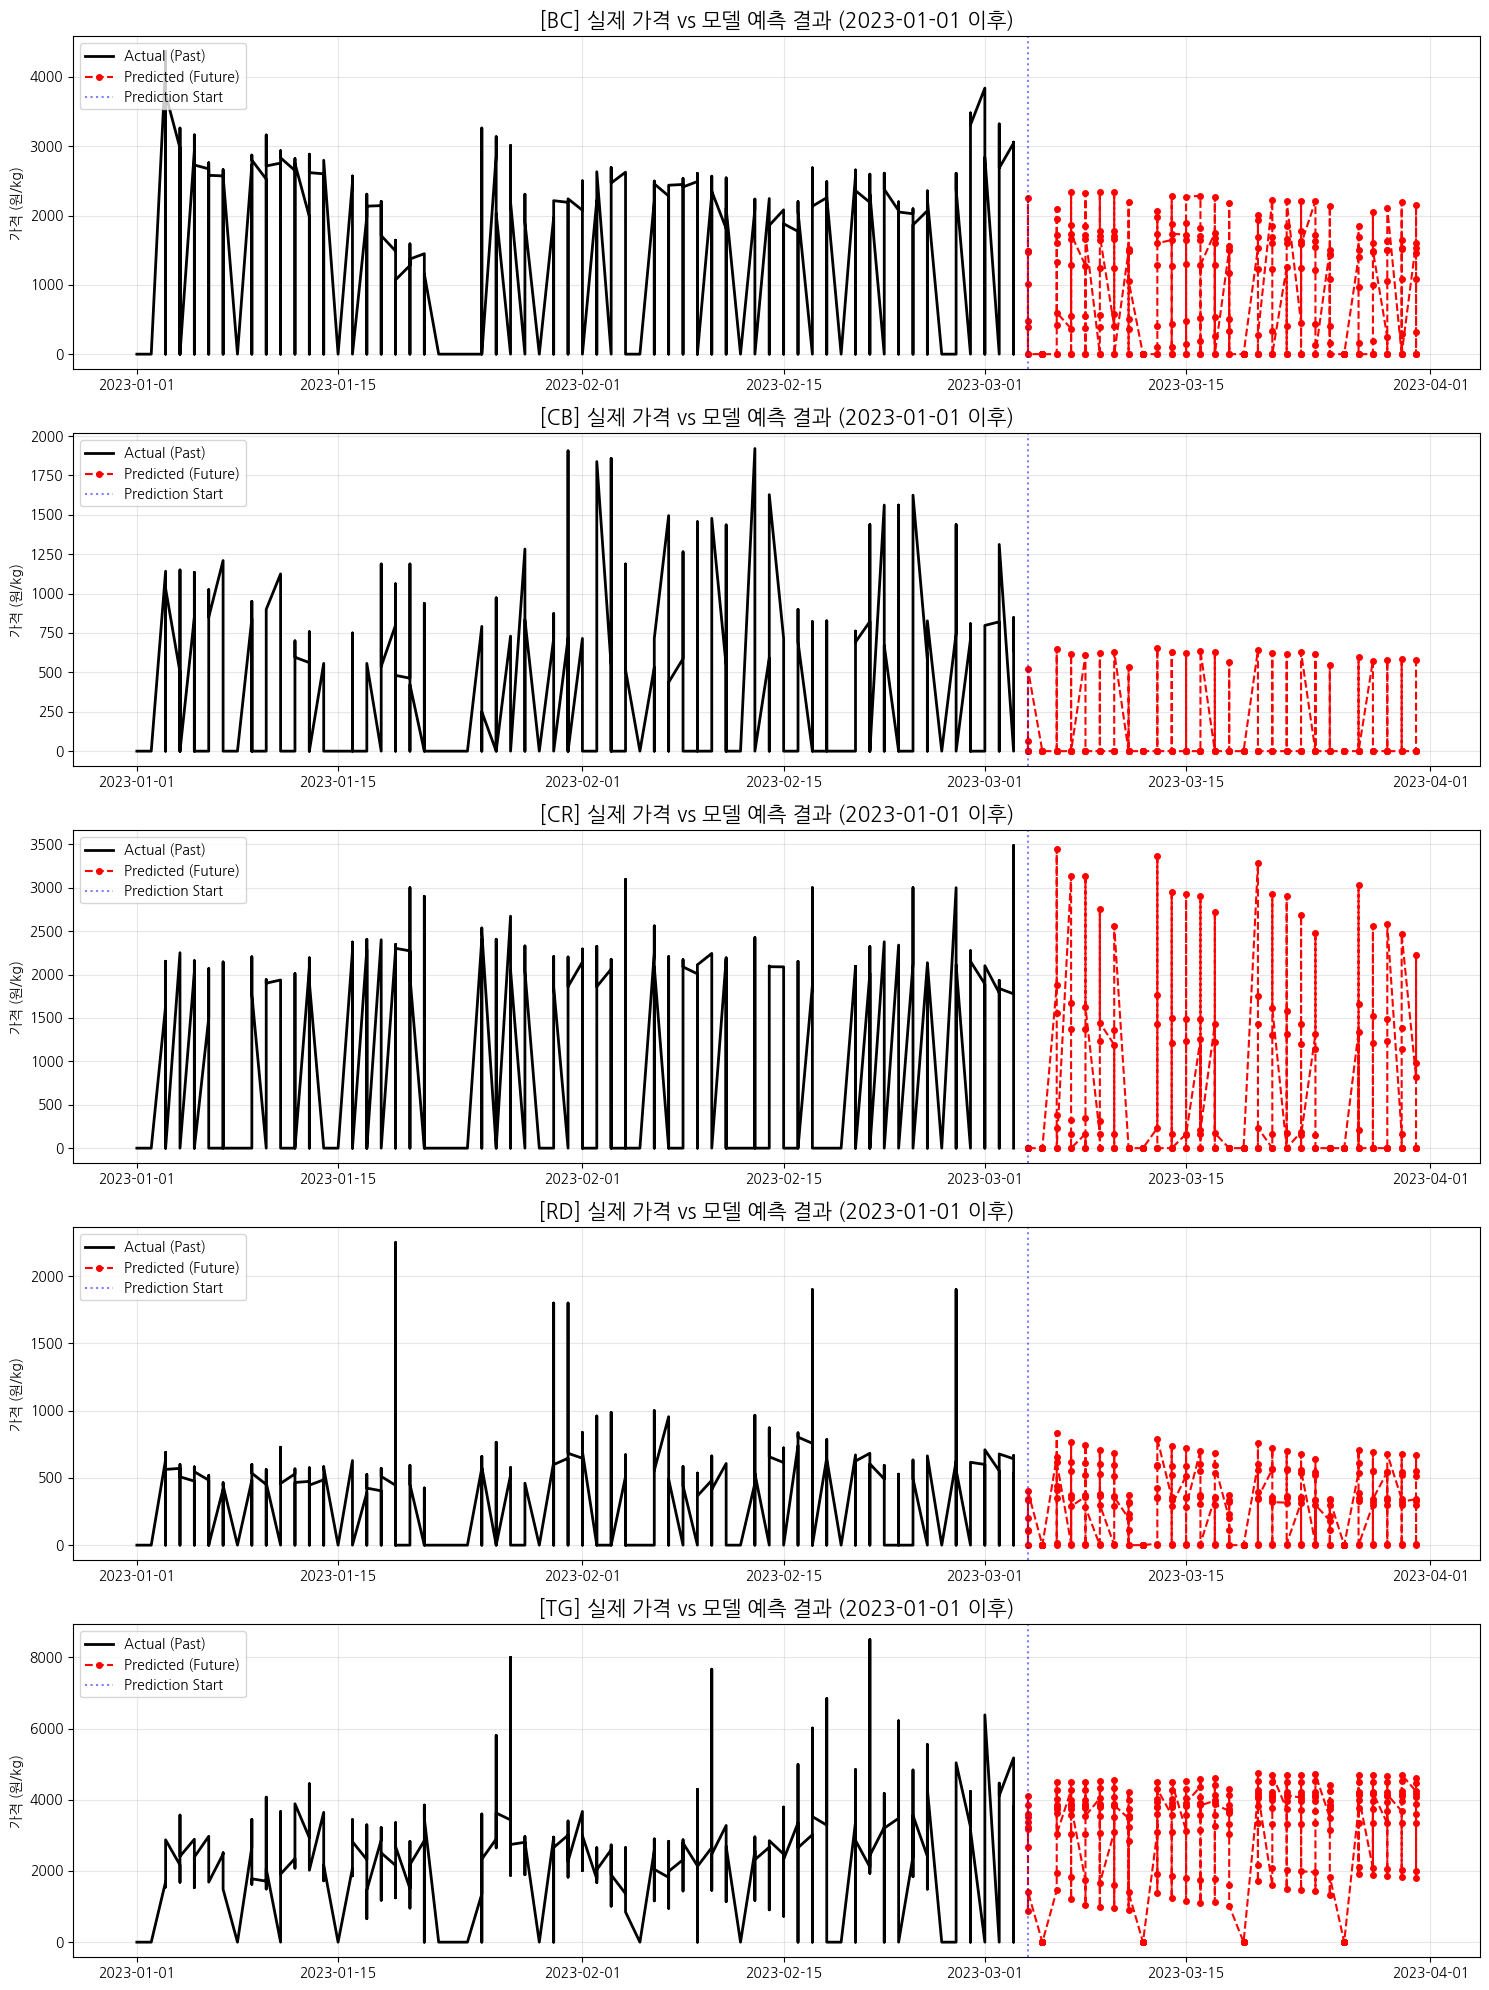

In [8]:
plt.figure(figsize=(15, 20))
viz_start_date = '2023-01-01'

for i, item_name in enumerate(items):
    plt.subplot(5, 1, i+1)
    
    # 1. 과거 실제 데이터 (Train)
    actual = train[(train['item'] == item_name) & (train['timestamp'] >= viz_start_date)].sort_values('timestamp')
    
    # 2. 모델 예측 데이터 (Test)
    # LabelEncoding된 item 코드를 다시 이름으로 매칭하여 필터링
    item_code = item_codes[item_name]
    pred = final_df[final_df['item'] == item_code].sort_values('timestamp')
    
    # 시각화
    plt.plot(actual['timestamp'], actual['price(원/kg)'], label='Actual (Past)', color='black', linewidth=2)
    plt.plot(pred['timestamp'], pred['answer'], label='Predicted (Future)', color='red', linestyle='--', marker='o', markersize=4)
    
    # 3월 4일(예측 시작일) 표시
    plt.axvline(pd.Timestamp('2023-03-04'), color='blue', linestyle=':', alpha=0.5, label='Prediction Start')
    
    plt.title(f'[{item_name}] 실제 가격 vs 모델 예측 결과 (2023-01-01 이후)', fontsize=15)
    plt.ylabel('가격 (원/kg)')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()